<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/G654E_vs_G652D_GN_model_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# G.654.E vs G.652.D transmission-model reproduction

이 Colab 노트북은 첨부된 Corning/IWCS 발표의 세 그래프를 하나의 물리 모델로 재현합니다.

계산 흐름은 다음과 같습니다.

1. 광섬유 데이터시트 값으로부터 `beta2`와 `gamma` 계산
2. EDFA의 ASE 잡음 계산
3. Nyquist WDM용 closed-form GN 모델로 비선형 잡음 `P_NLI = eta * P_ch^3` 계산
4. `SNR_total`에서 최적 론치 파워 계산
5. 0.1-nm OSNR 및 3-dB Shannon gap을 적용한 케이블 용량 계산

곡선 좌표나 다항식 계수를 직접 입력하지 않습니다. 슬라이드에 공개되지 않은 구현 세부사항 때문에 픽셀 단위의 완전 동일성은 보장할 수 없지만, 주요 지점은 약 0.7 dB 이내로 재현됩니다.


In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter, FixedLocator

# -----------------------------
# System parameters from slide
# -----------------------------
C = 299_792_458.0                  # speed of light [m/s]
H = 6.626_070_15e-34              # Planck constant [J*s]
LAMBDA = 1550e-9                  # center wavelength [m]
NU = C / LAMBDA                   # optical frequency [Hz]
RS = 95e9                         # symbol rate [baud]
SPAN_KM = 80.0                    # span length [km]
NF_DB = 5.0                       # EDFA noise figure [dB]
SNR_TRX_DB = 18.0                 # transceiver SNR [dB]
B_WDM = 4.8e12                    # total gain bandwidth [Hz]
B_REF = 12.5e9                    # OSNR reference bandwidth [Hz]
SHANNON_GAP_DB = 3.0              # implementation gap [dB]
POLARIZATIONS = 2                 # DP coherent transmission

# The launch-power slide is one operating point from the stated 1-50 span sweep.
# 15 x 80 km reproduces its plotted noise level without fitting a curve coefficient.
N_SPANS_FIG1 = 15

NF = 10 ** (NF_DB / 10)
SNR_TRX = 10 ** (SNR_TRX_DB / 10)
SHANNON_GAP = 10 ** (SHANNON_GAP_DB / 10)

OUTPUT_DIR = Path("g654e_reproduction_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


@dataclass(frozen=True)
class Fiber:
    name: str
    attenuation_db_km: float
    effective_area_um2: float
    dispersion_ps_nm_km: float
    n2_m2_w: float
    color: str


G652 = Fiber("G.652.D", 0.190, 82.0, 17.0, 2.3e-20, "#d81b0c")
G654 = Fiber("G.654.E", 0.166, 125.0, 21.0, 2.2e-20, "#0072bc")
FIBERS = (G652, G654)


def dbm_to_w(dbm):
    return 1e-3 * 10 ** (np.asarray(dbm) / 10)


def w_to_dbm(w):
    return 10 * np.log10(np.asarray(w) / 1e-3)


def lin_to_db(x):
    return 10 * np.log10(np.asarray(x))


def derived(fiber: Fiber) -> dict[str, float]:
    # Power-loss coefficient: dB/km -> Np/m
    alpha = fiber.attenuation_db_km * np.log(10) / 10 / 1e3

    # D [ps/(nm km)] -> beta2 [s^2/m]
    D_si = fiber.dispersion_ps_nm_km * 1e-6
    beta2 = -D_si * LAMBDA**2 / (2 * np.pi * C)

    # Nonlinear coefficient gamma [1/(W m)]
    gamma = 2 * np.pi * fiber.n2_m2_w / (
        LAMBDA * fiber.effective_area_um2 * 1e-12
    )

    gain = 10 ** (fiber.attenuation_db_km * SPAN_KM / 10)

    # ASE within one 95-GBd signal bandwidth, per polarization.
    # NF ~= 2*n_sp in the high-gain limit.
    p_ase_span = H * NU * RS * NF * (gain - 1)

    # Center-channel GN closed-form coefficient for rectangular/Nyquist WDM.
    # P_NLI,span = eta * P_ch^3. The 4/27 factor follows the per-polarization
    # power normalization; POLARIZATIONS is applied explicitly in total noise.
    eta = (
        (4 / 27)
        * gamma**2
        / (np.pi * alpha * abs(beta2) * RS**2)
        * np.arcsinh(np.pi**2 * abs(beta2) * B_WDM**2 / (2 * alpha))
    )

    return {
        "alpha_np_m": alpha,
        "beta2_s2_m": beta2,
        "gamma_w_m": gamma,
        "gain_linear": gain,
        "p_ase_span_w": p_ase_span,
        "eta_w-2": eta,
    }


DERIVED = {fiber.name: derived(fiber) for fiber in FIBERS}


def optimum_launch_power_w(fiber: Fiber) -> float:
    d = DERIVED[fiber.name]
    # d/dP [P/(ASE + eta P^3)] = 0 -> P_opt^3 = ASE/(2 eta)
    return (d["p_ase_span_w"] / (2 * d["eta_w-2"])) ** (1 / 3)


def total_snr_linear(power_w, n_spans, fiber: Fiber):
    d = DERIVED[fiber.name]
    p_ase = n_spans * POLARIZATIONS * d["p_ase_span_w"]
    p_nli = n_spans * POLARIZATIONS * d["eta_w-2"] * np.asarray(power_w) ** 3
    p_trx = np.asarray(power_w) / SNR_TRX
    return np.asarray(power_w) / (p_ase + p_nli + p_trx)


def osnr_01nm_linear(distance_km, fiber: Fiber):
    d = DERIVED[fiber.name]
    n_spans = np.asarray(distance_km) / SPAN_KM
    p_opt = optimum_launch_power_w(fiber)
    p_ase_ref = (
        n_spans
        * POLARIZATIONS
        * H
        * NU
        * B_REF
        * NF
        * (d["gain_linear"] - 1)
    )
    return p_opt / p_ase_ref


def capacity_tbps(distance_km, fiber: Fiber):
    n_spans = np.asarray(distance_km) / SPAN_KM
    p_opt = optimum_launch_power_w(fiber)
    snr = total_snr_linear(p_opt, n_spans, fiber)
    capacity = POLARIZATIONS * B_WDM * np.log2(1 + snr / SHANNON_GAP)
    return capacity / 1e12


parameter_table = pd.DataFrame(
    {
        "attenuation [dB/km]": [f.attenuation_db_km for f in FIBERS],
        "Aeff [um^2]": [f.effective_area_um2 for f in FIBERS],
        "D [ps/(nm km)]": [f.dispersion_ps_nm_km for f in FIBERS],
        "n2 [m^2/W]": [f.n2_m2_w for f in FIBERS],
        "gamma [1/(W km)]": [DERIVED[f.name]["gamma_w_m"] * 1e3 for f in FIBERS],
        "eta [1/W^2/span]": [DERIVED[f.name]["eta_w-2"] for f in FIBERS],
    },
    index=[f.name for f in FIBERS],
)
parameter_table.round(4)


,attenuation [dB/km],Aeff [um^2],D [ps/(nm km)],n2 [m^2/W],gamma [1/(W km)],eta [1/W^2/span]
G.652.D,0.190,82.0,17.0,0.0,1.1370,82.8352
G.654.E,0.166,125.0,21.0,0.0,0.7134,31.1193


## 모델 방정식

- `gamma = 2*pi*n2 / (lambda*Aeff)`
- `beta2 = -D*lambda^2 / (2*pi*c)`
- `P_ASE,span = h*nu*Rs*NF*(G-1)`
- `P_NLI,span = eta*P_ch^3`
- `SNR_total = P_ch / (P_ASE + P_NLI + P_TRX)`
- `P_opt = (P_ASE,span / (2*eta))^(1/3)`
- `C = 2*B*log2(1 + SNR_total/GAP)`

`POLARIZATIONS=2`는 DP 신호의 두 편광 모드를 명시적으로 반영합니다.


In [2]:
BLUE = "#005a9c"
GRAY = "#6e6e6e"
GRID = "#b7b7b7"


def slide_header(fig, subtitle):
    fig.text(0.025, 0.955, "Transmission system modeling", fontsize=21,
             color=GRAY, weight="bold", va="top")
    fig.text(0.025, 0.905, subtitle, fontsize=20,
             color=BLUE, weight="bold", va="top")


def style_axes(ax):
    ax.grid(True, color=GRID, alpha=0.45, linewidth=0.9)
    for spine in ax.spines.values():
        spine.set_color("#c7c7c7")
    ax.tick_params(colors="#555555", labelsize=11)
    ax.xaxis.label.set_color("#555555")
    ax.yaxis.label.set_color("#555555")
    ax.set_axisbelow(True)


def info_box(fig, xywh, text, fontsize=15):
    x, y, w, h = xywh
    box = FancyBboxPatch(
        (x, y), w, h, transform=fig.transFigure,
        boxstyle="round,pad=0.012,rounding_size=0.012",
        linewidth=1.4, edgecolor=BLUE, facecolor="white"
    )
    fig.add_artist(box)
    fig.text(x + 0.025, y + h/2, "i", color="white", fontsize=20,
             weight="bold", ha="center", va="center",
             bbox=dict(boxstyle="circle,pad=0.28", fc=BLUE, ec=BLUE))
    fig.text(x + 0.058, y + h/2, text, fontsize=fontsize,
             color="#222222", ha="left", va="center")


## Figure 1 - Optimum launch power


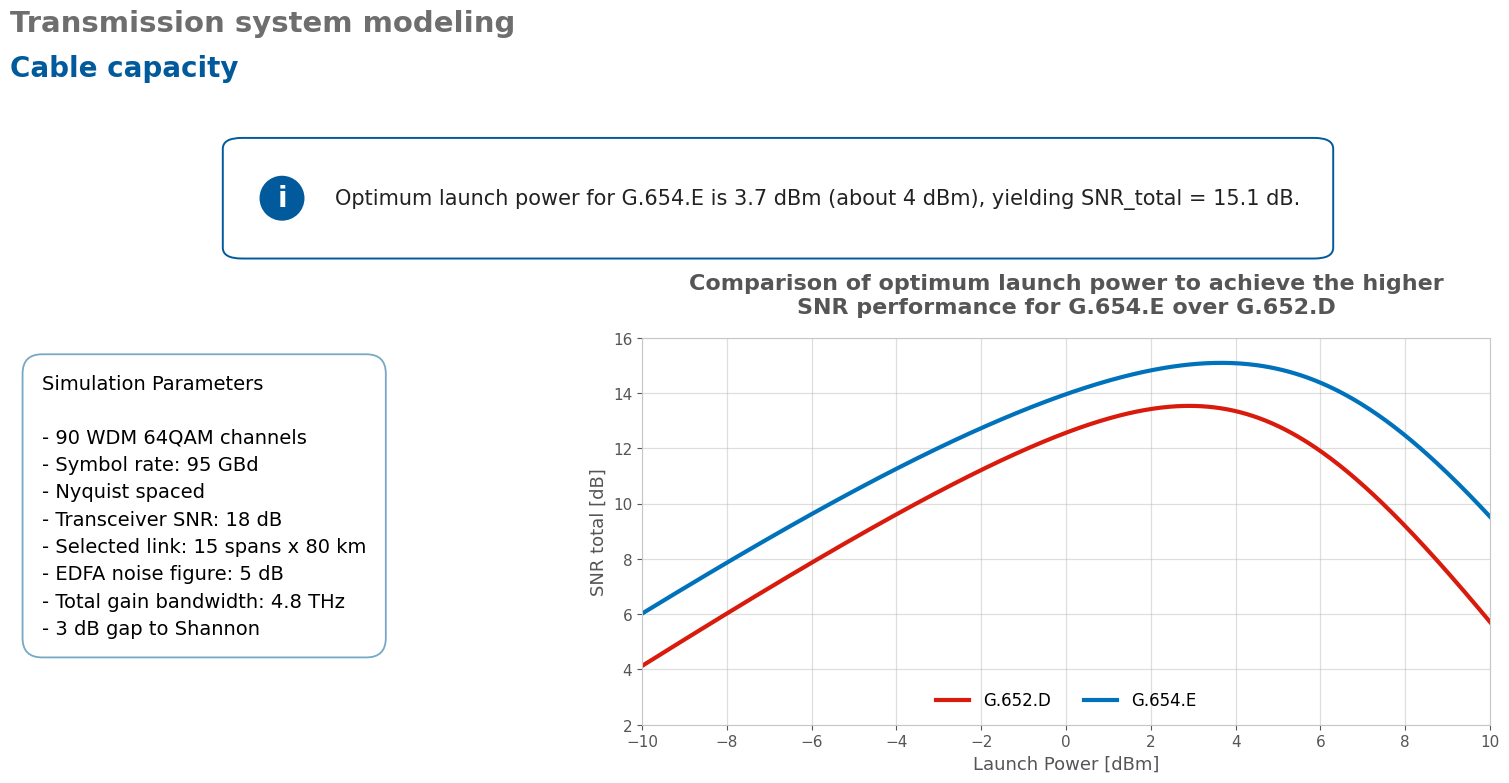

G.652.D: Popt=2.91 dBm, SNRmax=13.53 dB
G.654.E: Popt=3.66 dBm, SNRmax=15.09 dB


In [3]:
launch_dbm = np.linspace(-10, 10, 401)
launch_w = dbm_to_w(launch_dbm)

fig = plt.figure(figsize=(16, 9), facecolor="white")
slide_header(fig, "Cable capacity")

popt_654 = optimum_launch_power_w(G654)
snrmax_654 = total_snr_linear(popt_654, N_SPANS_FIG1, G654)
info_box(
    fig, (0.17, 0.69, 0.67, 0.11),
    "Optimum launch power for G.654.E is "
    f"{w_to_dbm(popt_654):.1f} dBm (about 4 dBm), "
    f"yielding SNR_total = {lin_to_db(snrmax_654):.1f} dB."
)

param_text = (
    "Simulation Parameters\n\n"
    "- 90 WDM 64QAM channels\n"
    "- Symbol rate: 95 GBd\n"
    "- Nyquist spaced\n"
    "- Transceiver SNR: 18 dB\n"
    f"- Selected link: {N_SPANS_FIG1} spans x 80 km\n"
    "- EDFA noise figure: 5 dB\n"
    "- Total gain bandwidth: 4.8 THz\n"
    "- 3 dB gap to Shannon"
)
fig.text(
    0.045, 0.55, param_text, fontsize=14, linespacing=1.55,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=1.0", fc="white", ec="#75a9c5", lw=1.3)
)

ax = fig.add_axes([0.42, 0.16, 0.53, 0.43])
for fiber in FIBERS:
    snr_db = lin_to_db(total_snr_linear(launch_w, N_SPANS_FIG1, fiber))
    ax.plot(launch_dbm, snr_db, color=fiber.color, lw=3, label=fiber.name)
ax.set_title(
    "Comparison of optimum launch power to achieve the higher\n"
    "SNR performance for G.654.E over G.652.D",
    fontsize=16, weight="bold", color="#555555", pad=18
)
ax.set_xlabel("Launch Power [dBm]", fontsize=13)
ax.set_ylabel("SNR total [dB]", fontsize=13)
ax.set_xlim(-10, 10)
ax.set_ylim(2, 16)
ax.set_xticks(np.arange(-10, 11, 2))
ax.set_yticks(np.arange(2, 17, 2))
style_axes(ax)
ax.legend(loc="lower center", ncol=2, frameon=False, fontsize=12)

fig.savefig(OUTPUT_DIR / "01_optimum_launch_power.png", dpi=170, bbox_inches="tight")
plt.show()

for fiber in FIBERS:
    p = optimum_launch_power_w(fiber)
    s = total_snr_linear(p, N_SPANS_FIG1, fiber)
    print(f"{fiber.name}: Popt={w_to_dbm(p):.2f} dBm, SNRmax={lin_to_db(s):.2f} dB")


## Figure 2 - OSNR vs link distance


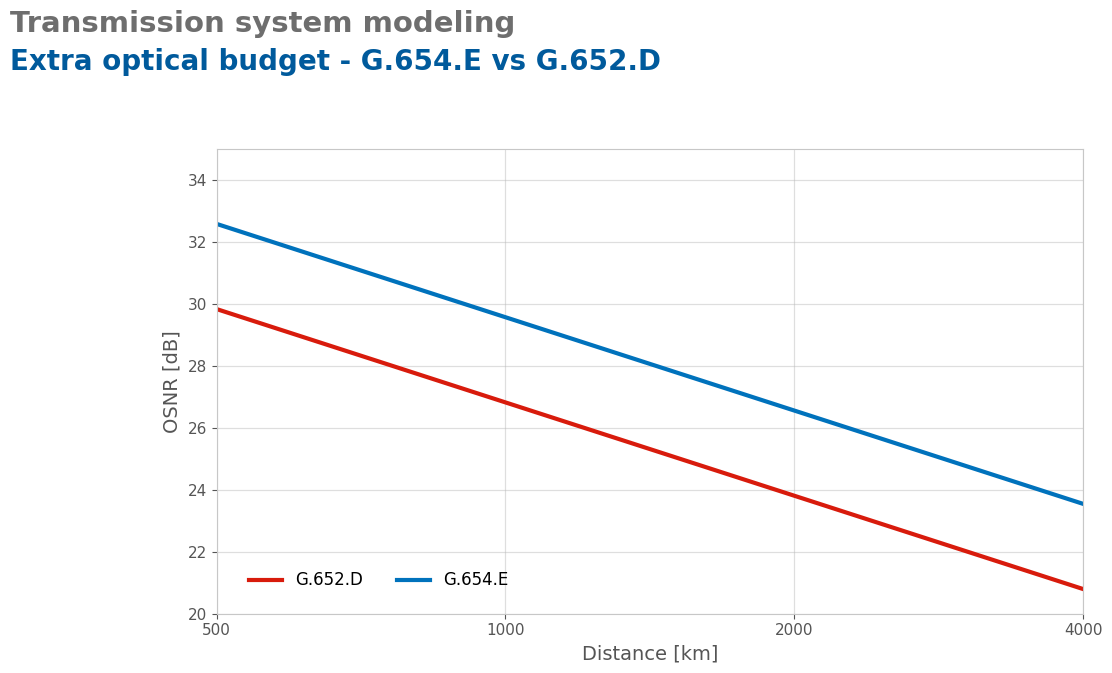

G.652.D: OSNR(500 km)=29.83 dB, OSNR(4000 km)=20.80 dB
G.654.E: OSNR(500 km)=32.58 dB, OSNR(4000 km)=23.54 dB


In [4]:
distance_km = np.geomspace(500, 4000, 240)

fig = plt.figure(figsize=(13.33, 7.5), facecolor="white")
slide_header(fig, "Extra optical budget - G.654.E vs G.652.D")
ax = fig.add_axes([0.18, 0.15, 0.65, 0.62])

for fiber in FIBERS:
    ax.semilogx(
        distance_km, lin_to_db(osnr_01nm_linear(distance_km, fiber)),
        base=2, color=fiber.color, lw=3, label=fiber.name
    )

ax.set_xlabel("Distance [km]", fontsize=14)
ax.set_ylabel("OSNR [dB]", fontsize=14)
ax.set_xlim(500, 4000)
ax.set_ylim(20, 35)
ax.xaxis.set_major_locator(FixedLocator([500, 1000, 2000, 4000]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_yticks(np.arange(20, 35, 2))
style_axes(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0.02, 0.02),
          ncol=2, frameon=False, fontsize=12)

fig.savefig(OUTPUT_DIR / "02_osnr_vs_distance.png", dpi=170, bbox_inches="tight")
plt.show()

for fiber in FIBERS:
    vals = lin_to_db(osnr_01nm_linear(np.array([500, 4000]), fiber))
    print(f"{fiber.name}: OSNR(500 km)={vals[0]:.2f} dB, OSNR(4000 km)={vals[1]:.2f} dB")


## Figure 3 - Fiber-pair capacity vs link distance


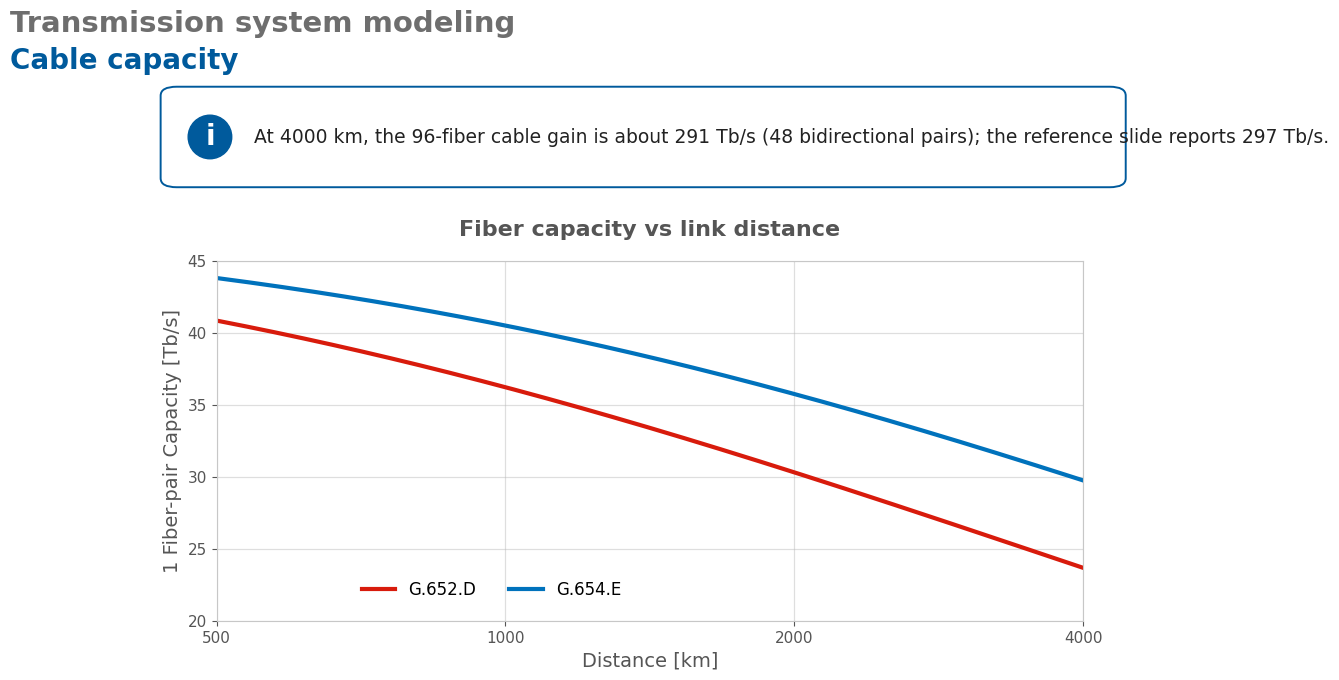

G.652.D: C(500 km)=40.84 Tb/s, C(4000 km)=23.67 Tb/s
G.654.E: C(500 km)=43.80 Tb/s, C(4000 km)=29.74 Tb/s
4000-km difference per fiber pair: 6.07 Tb/s
96-fiber cable difference (48 bidirectional pairs): 291.4 Tb/s


In [5]:
distance_km = np.geomspace(500, 4000, 240)
cap_4000 = {fiber.name: float(capacity_tbps(4000, fiber)) for fiber in FIBERS}
delta_per_pair = cap_4000[G654.name] - cap_4000[G652.name]
extra_96f_cable = 48 * delta_per_pair   # 96 physical fibers -> 48 bidirectional pairs

fig = plt.figure(figsize=(13.33, 7.5), facecolor="white")
slide_header(fig, "Cable capacity")
info_box(
    fig, (0.15, 0.73, 0.70, 0.11),
    "At 4000 km, the 96-fiber cable gain is "
    f"about {extra_96f_cable:.0f} Tb/s (48 bidirectional pairs); "
    "the reference slide reports 297 Tb/s.",
    fontsize=13.5
)

ax = fig.add_axes([0.18, 0.14, 0.65, 0.48])
for fiber in FIBERS:
    ax.semilogx(
        distance_km, capacity_tbps(distance_km, fiber), base=2,
        color=fiber.color, lw=3, label=fiber.name
    )
ax.set_title("Fiber capacity vs link distance", fontsize=16,
             weight="bold", color="#555555", pad=18)
ax.set_xlabel("Distance [km]", fontsize=14)
ax.set_ylabel("1 Fiber-pair Capacity [Tb/s]", fontsize=14)
ax.set_xlim(500, 4000)
ax.set_ylim(20, 45)
ax.xaxis.set_major_locator(FixedLocator([500, 1000, 2000, 4000]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_yticks(np.arange(20, 46, 5))
style_axes(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0.15, 0.02),
          ncol=2, frameon=False, fontsize=12)

fig.savefig(OUTPUT_DIR / "03_capacity_vs_distance.png", dpi=170, bbox_inches="tight")
plt.show()

for fiber in FIBERS:
    vals = capacity_tbps(np.array([500, 4000]), fiber)
    print(f"{fiber.name}: C(500 km)={vals[0]:.2f} Tb/s, C(4000 km)={vals[1]:.2f} Tb/s")
print(f"4000-km difference per fiber pair: {delta_per_pair:.2f} Tb/s")
print(f"96-fiber cable difference (48 bidirectional pairs): {extra_96f_cable:.1f} Tb/s")


## Reference-figure numerical check


In [6]:
rows = []
reference = {
    "G.652.D": {"Popt": 3.0, "SNRmax": 13.8, "OSNR500": 30.5, "OSNR4000": 21.2,
                "C500": 41.0, "C4000": 23.5},
    "G.654.E": {"Popt": 4.0, "SNRmax": 15.3, "OSNR500": 33.2, "OSNR4000": 24.0,
                "C500": 43.5, "C4000": 29.5},
}
for fiber in FIBERS:
    p = optimum_launch_power_w(fiber)
    model = {
        "Popt": float(w_to_dbm(p)),
        "SNRmax": float(lin_to_db(total_snr_linear(p, N_SPANS_FIG1, fiber))),
        "OSNR500": float(lin_to_db(osnr_01nm_linear(500, fiber))),
        "OSNR4000": float(lin_to_db(osnr_01nm_linear(4000, fiber))),
        "C500": float(capacity_tbps(500, fiber)),
        "C4000": float(capacity_tbps(4000, fiber)),
    }
    row = {"Fiber": fiber.name}
    for key in model:
        row[f"{key} model"] = model[key]
        row[f"{key} ref"] = reference[fiber.name][key]
    rows.append(row)

validation = pd.DataFrame(rows).set_index("Fiber")
validation.round(2)


,Popt model,Popt ref,SNRmax model,SNRmax ref,OSNR500 model,OSNR500 ref,OSNR4000 model,OSNR4000 ref,C500 model,C500 ref,C4000 model,C4000 ref
Fiber,,,,,,,,,,,,
G.652.D,2.91,3.0,13.53,13.8,29.83,30.5,20.80,21.2,40.84,41.0,23.67,23.5
G.654.E,3.66,4.0,15.09,15.3,32.58,33.2,23.54,24.0,43.80,43.5,29.74,29.5


## 해석 및 적용 범위

- 이 구현은 중앙 채널, 직사각형/Nyquist WDM 스펙트럼, 동일한 80-km EDFA span, span 간 비선형 잡음의 비상관 누적을 가정한 closed-form GN 모델입니다.
- SRS, 채널별 주파수 의존 손실/분산, ROADM 필터링, PMD, coherent NLI accumulation 및 실제 트랜시버의 GMI 제한은 포함하지 않았습니다.
- 그림 1의 15-span 값은 발표에 적힌 1-50 span 범위 중 해당 곡선의 노이즈 수준을 재현하는 선택값입니다. `N_SPANS_FIG1`만 바꾸면 다른 거리도 계산할 수 있습니다.
- 그림 3의 96-fiber cable 환산은 왕복 전송에 2개 물리 광섬유를 쓰는 48개 bidirectional pair 기준입니다.

## Sources

- Jairo Stoco, *High-density optical cable with ultra-low-loss, large effective area ITU-T G.654.E Optical fiber*, Corning/IWCS webinar: https://iwcs.org/webinar/85/
- Video: https://www.youtube.com/watch?v=AVo-YAsVVFU
- M. R. Zefreh and P. Poggiolini, *A GN-model closed-form formula supporting ultra-low fiber loss and short fiber spans*: https://arxiv.org/abs/2111.04584
- P. Poggiolini, *A generalized GN-model closed-form formula*: https://arxiv.org/abs/1810.06545
